# Secrecy — the one-time pad, the key-distribution problem, authentication and privacy amplification

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 14 — Quantum communication and cryptography*

## 1. Introduction and motivation

Alice wants to tell Bob something that nobody else may read: a bank transfer, a medical record, the time of a
meeting. The only connection between them is a public channel, a radio link or a fibre that an eavesdropper, Eve, can
tap. Whatever Alice sends, Eve receives too. Secrecy therefore cannot come from hiding the signal; it has to come
from something that Bob knows and Eve does not. That something is a **secret key**. Three questions follow: how
much key secrecy requires, what goes wrong when the key is misused, and how the key reaches Bob in the first place.

[Notebook 50](../ch14_quantum_communication_and_cryptography/50_information_entropy_and_noisy_channels.ipynb) gave
the language: entropy measures uncertainty, and the mutual information $I(X{:}Y)$ measures how much one variable
reveals about another. In 1949 Shannon used exactly this language to define what it means for a cipher to be
unbreakable, and he proved that a simple cipher, the **one-time pad**, achieves it (Shannon 1949).

![The one-time pad: Alice adds the key to the message, the ciphertext crosses a public channel read by Eve, Bob adds the same key, and the key itself has to reach both in advance](figures/one_time_pad.svg)

**Figure 1.** The one-time pad. Alice adds a secret random key $k$ to her message $m$ bit by bit, $c=m\oplus k$, and
sends the ciphertext $c$ over a public channel. Eve reads $c$, but her probabilities for the possible messages stay
exactly what they were before (Section 5). Bob adds the same key and recovers $m$, because $k\oplus k=0$. The key must
be uniformly random, secret, as long as the message and used only once (Section 6), and both copies must reach Alice
and Bob in advance without passing through a channel that Eve can read, which is the key-distribution problem
(Section 7).

**The idea.** Adding a uniformly random bit to a message bit produces a uniformly random bit, whatever the message
bit was. A ciphertext made this way is pure noise to anyone who lacks the key, so it carries no information about the
message, and Bob, who holds the key, removes the noise exactly. The price is one fresh secret key bit for every
message bit. Moving that much key between distant parties is the problem that quantum key distribution solves. Two
more classical ingredients are needed before quantum mechanics enters. Alice and Bob must be sure that they talk to
each other and not to Eve, which is the task of authentication, and they must be able to remove the partial
knowledge that Eve may hold about a shared key, which is the task of privacy amplification.

### 1.1 Road map

* **Section 3** introduces the cast, the kinds of channels and the threat model, with Kerckhoffs's principle.
* **Section 4** defines perfect secrecy through probabilities and through the mutual information.
* **Section 5** proves that the one-time pad is perfectly secret and checks it by simulation on text and on random
  messages.
* **Section 6** breaks the one-time pad in three ways: a key used twice, a biased key and a key shorter than the
  message. The last one is Shannon's theorem $H(K)\geq H(M)$.
* **Section 7** states the key-distribution problem and contrasts computational with information-theoretic security,
  including the threat of "store now, decrypt later".
* **Section 8** shows that secrecy does not protect against tampering, simulates the man-in-the-middle attack and
  explains why every key-distribution scheme, quantum ones included, starts from a short authentication key.
* **Section 9** shrinks a partly compromised key into a shorter secret one: privacy amplification, first with two
  bits and then with random linear hash functions.
* **Section 10** connects these pieces with quantum key distribution.

### What you will learn

*Cryptography and information*

* what a threat model is, and why a security claim without one has no meaning;
* perfect secrecy as $P(M\vert C)=P(M)$, equivalently $I(M{:}C)=0$, and the proof that the one-time pad achieves it;
* why the key must be uniform, secret, at least as long as the message and used only once, with the leak of each
  mistake quantified in bits;
* the difference between computational and information-theoretic security;
* why encryption does not authenticate, how the man-in-the-middle attack works, and why quantum key distribution
  grows a key from a short pre-shared one;
* how hashing a key to a shorter one removes an eavesdropper's partial knowledge.

*Numerical methods*

* exact joint distributions of message and ciphertext by enumeration, and plug-in mutual information from samples;
* entropies of linear functions of random bits from ranks of binary matrices, checked by brute force.

*Implementation practice*

* text as bit strings, encryption and decryption as XOR on arrays;
* wrong controls that must fail: a reused key that reveals both messages, a biased key that Eve exploits, a key
  shorter than the message, a tampered ciphertext, a reused authentication key, and a fixed hash that keeps the bits
  Eve knows.

### Prerequisites

* [Notebook 50](../ch14_quantum_communication_and_cryptography/50_information_entropy_and_noisy_channels.ipynb),
  Sections 3 and 4: entropy, the binary entropy $h(q)$, conditional entropy, the chain rule and the mutual
  information; Section 5.1, the binary symmetric channel; Section 6.3, the public parity checks that correct a shared
  key.
* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): arrays and pseudo-random keys.
* Basic probability: conditional probability and Bayes' rule.

No quantum mechanics is needed here either; it enters in the quantum part of this chapter.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Notebook helpers

As in notebook 50, every experiment draws its random numbers from its own key, `jax.random.fold_in(MASTER, i)`, so
that the experiments are independent and reproducible one by one. The entropy functions are the ones of notebook 50,
Eqs. (2), (4) and (8)–(10) there. Two small helpers turn text into bits and back: each character is one byte of
ASCII code, eight bits, most significant bit first. Characters that are not printable are shown as `·`, so that a
ciphertext can be printed as a line of text.

In [2]:
# ==============================================================================
# PLOT STYLE + small helpers (entropy functions as in notebook 50)
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})

MASTER = jax.random.PRNGKey(51)          # one master key per run; experiment i uses fold_in(MASTER, i)


def key_for(i):
    """Independent key for experiment number i."""
    return jax.random.fold_in(MASTER, i)


def numpy_rng(i):
    """numpy Generator seeded from experiment key i (for permutations and integer draws)."""
    return np.random.default_rng(int(jax.random.randint(key_for(i), (), 0, 2**31 - 1)))


def random_bits(key, n, p=0.5):
    """n independent bits, each equal to 1 with probability p (numpy uint8 array)."""
    return np.asarray(jax.random.bernoulli(key, p, (n,)), dtype=np.uint8)


def entropy(probs):
    """Shannon entropy in bits of a probability vector or table (notebook 50, Eq. (2)); 0 log 0 = 0."""
    p = np.asarray(probs, dtype=float).ravel()
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum()) + 0.0


def h2(q):
    """Binary entropy h(q) = -q log2 q - (1-q) log2(1-q) (notebook 50, Eq. (4)); scalars and arrays."""
    q = np.asarray(q, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        out = -q * np.log2(np.where(q > 0, q, 1.0)) - (1 - q) * np.log2(np.where(q < 1, 1 - q, 1.0))
    return out if out.ndim else float(out)


def info_quantities(pxy):
    """Joint table p(x, y) -> H(X), H(Y), H(X,Y), H(X|Y), I(X:Y) (notebook 50, Eqs. (8)-(10))."""
    pxy = np.asarray(pxy, dtype=float)
    HX, HY, HXY = entropy(pxy.sum(1)), entropy(pxy.sum(0)), entropy(pxy)
    return {"H(X)": HX, "H(Y)": HY, "H(X,Y)": HXY, "H(X|Y)": HXY - HY, "I(X:Y)": HX + HY - HXY}


def binom_se(p, n):
    """Standard error of an observed frequency p from n independent trials."""
    return float(np.sqrt(max(p * (1 - p), 1e-300) / n))


def text_to_bits(s):
    """ASCII text -> bit array (8 bits per character, most significant bit first)."""
    return np.unpackbits(np.frombuffer(s.encode("ascii"), dtype=np.uint8))


def bits_to_text(bits):
    """Bit array -> text; bytes that are not printable ASCII are shown as a middle dot."""
    return "".join(chr(b) if 32 <= b < 127 else "·" for b in np.packbits(bits))

## 3. The cast, the channels and the threat model

### 3.1 Alice, Bob and Eve

Papers on cryptography tell short stories with a fixed cast, and each name stands for a precise role. **Alice** sends
and **Bob** receives. Both are *honest parties* in the technical sense of the field: they follow the **protocol**, the
complete public list of instructions that says who computes, sends and checks what and when. **Eve** is the
adversary. A *passive* Eve only listens, like someone who reads every postcard passing through a post office; an
*active* Eve can also stop, change, replace or inject messages and can pretend to be Alice or Bob. Between the two
extremes lies the *honest-but-curious* party, who follows the protocol to the letter but keeps a copy of everything
it legitimately sees and tries to learn from it later, like a courier who delivers every envelope unopened but
photographs every postcard. A protocol that is secure against a curious party may fail against a malicious one, so
the distinction matters whenever a third party takes part.

### 3.2 Private, public and authenticated channels

Cryptography distinguishes channels by who can read them and who can write into them. A **private channel** can be
read only by the intended receiver, like a sealed diplomatic pouch; with one, Alice and Bob would need no
cryptography at all. A **public channel** can be read by everyone, Eve included, like a radio broadcast, and an
active Eve can also write into it. A **public authenticated channel** can be read by everyone, but nobody can change,
insert or delete a message on it without being detected, like a notice board on which every notice carries an
unforgeable signature. Eve can read every notice and cannot post a fake one. Quantum key distribution assumes exactly
this kind of channel for its classical messages, and Section 8 shows what it takes to build one.

### 3.3 The threat model and Kerckhoffs's principle

"Secure" means nothing until one says *against whom*. A **threat model** is the precise list of what the adversary
is allowed to do, and it answers a few questions. Which parties follow the protocol, and which may be curious or
malicious? Which channels can Eve read, and which can she change? Can she reach stored data or devices before,
during or after the protocol? How much computing power does she have, and is it bounded at all? Which devices and
statistical assumptions are trusted? And what counts as a break: reading the message, changing it unnoticed, or
impersonating a party? A well-formed security statement fills in every blank: *against an adversary who can do
this, and assuming that, the protocol achieves such a goal*. Two examples show why. The one-time pad (Section 5)
is perfectly secure against anyone who sees only the ciphertext, and it offers no protection at all if Eve steals
the key from Bob's desk. A quantum key distribution system guarantees the secrecy of the key it produces, but Eve can
always cut the fibre, and then no key is produced; availability is not part of the promise.

One rule is part of every threat model. In 1883 Auguste Kerckhoffs listed the requirements of a military cipher, and
the second of them reads, in translation, that the system *must not require secrecy, and it must be able to fall into
the hands of the enemy without inconvenience* (Kerckhoffs 1883). **Kerckhoffs's principle** therefore says that Eve
knows the protocol, every algorithm and every device; only the key is secret. Shannon made the same assumption the
starting point of his theory: the enemy knows the system being used, including the probabilities with which keys are
chosen (Shannon 1949). A cipher whose security rests on a secret design is broken for good once the design leaks,
while a compromised key can simply be replaced.

## 4. Perfect secrecy

Alice's **message**, or plaintext, is a random variable $M$ with values $m$ and a probability distribution $P(m)$
that Eve may know: some messages are more likely than others, and Eve may have good guesses. Alice transforms $m$
with a **key** $k$, a value of the random variable $K$, into a **ciphertext** $c=E_k(m)$, the value of $C$, and sends
it over the public channel. This is **encryption**. Bob, who knows $k$, applies the inverse map, **decryption**,
$m=D_k(c)$. The key is chosen independently of the message.

Eve intercepts $c$. Before seeing it, her knowledge of the message is the prior $P(M=m)$; afterwards, by Bayes' rule,
it is the posterior $P(M=m\vert C=c)$. Shannon called a system **perfectly secret** when intercepting the ciphertext
gives the cryptanalyst no information, that is when the posterior equals the prior for every message and every
ciphertext (Shannon 1949, Section 10),

$$P(M=m\vert C=c)=P(M=m)\qquad\text{for all }m\text{ and all }c\text{ with }P(C=c)>0. \tag{1}$$

Equation (1) says that $M$ and $C$ are statistically independent, so their mutual information
([notebook 50](../ch14_quantum_communication_and_cryptography/50_information_entropy_and_noisy_channels.ipynb),
Eq. (10)) vanishes:

$$I(M{:}C)=H(M)-H(M\vert C)=0. \tag{2}$$

Conversely, $I(M{:}C)=0$ holds only for independent variables, so Eqs. (1) and (2) are the same condition. Bayes'
rule, $P(m\vert c)=P(m)\,P(c\vert m)/P(c)$, gives a third form that is easier to check, because it involves only the
cipher and the key: Eq. (1) holds exactly when

$$P(C=c\vert M=m)=P(C=c)\qquad\text{for all }m\text{ with }P(M=m)>0\text{ and all }c, \tag{3}$$

so that the probability of seeing a given ciphertext is the same whichever message was sent. This is Shannon's
Theorem 6. The definition asks for a lot and assumes little about Eve: she may know the cipher, the prior and every
key probability, and her computing power is unlimited. Seeing $c$ simply does not help her.

The next cell builds the exact joint table $P(m,c)=\sum_kP(m)P(k)\,[E_k(m)=c]$ for any small cipher by enumerating
all messages and keys, and evaluates Eqs. (1)–(3) on it. The first test cipher adds a uniform three-bit key to a
three-bit message with a strongly skewed prior; it is the one-time pad of the next section. The wrong control uses a
single key bit and adds it to all three message bits; it must fail all three tests.

In [3]:
# ==============================================================================
# Eqs. (1)-(3): perfect secrecy tested on the exact joint table of a small cipher
# ==============================================================================
def cipher_joint(P_M, P_K, encrypt, n_c):
    """Exact joint table P(m, c) = sum_k P(m) P(k) [encrypt(m, k) == c] for integer messages, keys, ciphertexts."""
    table = np.zeros((len(P_M), n_c))
    for m, pm in enumerate(P_M):
        for k, pk in enumerate(P_K):
            table[m, encrypt(m, k)] += pm * pk
    return table


def secrecy_report(table):
    """Largest violation of Eq. (1) and of Eq. (3), and I(M:C) of Eq. (2), for a joint table P(m, c)."""
    P_M, P_C = table.sum(1), table.sum(0)
    seen = P_C > 0
    posterior = table[:, seen] / P_C[seen]                              # P(m | c), columns = observed c
    likelihood = table / P_M[:, None]                                   # P(c | m), rows = messages
    return (float(np.max(np.abs(posterior - P_M[:, None]))),           # Eq. (1)
            float(np.max(np.abs(likelihood - P_C[None, :]))),           # Eq. (3)
            info_quantities(table)["I(X:Y)"])                           # Eq. (2)


PRIOR3 = np.array([0.50, 0.20, 0.10, 0.08, 0.06, 0.03, 0.02, 0.01])    # skewed prior on the 8 three-bit messages
H_M3 = entropy(PRIOR3)

otp3 = cipher_joint(PRIOR3, np.full(8, 1 / 8), lambda m, k: m ^ k, 8)              # 3-bit key, XOR
weak3 = cipher_joint(PRIOR3, np.full(2, 1 / 2), lambda m, k: m ^ (0b111 * k), 8)   # 1 key bit added to all 3 bits

print(f"H(M) = {H_M3:.4f} bits for the skewed prior")
for name, tab in [("3-bit key (one-time pad)", otp3), ("1 key bit on all 3 bits", weak3)]:
    d1, d3, I = secrecy_report(tab)
    print(f"{name:26s}: max |P(m|c) - P(m)| = {d1:.4f}, max |P(c|m) - P(c)| = {d3:.4f}, I(M:C) = {I:.4f} bits")
d1, d3, I = secrecy_report(otp3)
assert d1 < TOL and d3 < TOL and abs(I) < TOL                          # Eqs. (1)-(3) hold
d1, d3, I_weak = secrecy_report(weak3)
assert d1 > 0.1 and d3 > 0.1 and I_weak > 1.0                          # wrong control: all three fail

H(M) = 2.1627 bits for the skewed prior
3-bit key (one-time pad)  : max |P(m|c) - P(m)| = 0.0000, max |P(c|m) - P(c)| = 0.0000, I(M:C) = 0.0000 bits
1 key bit on all 3 bits   : max |P(m|c) - P(m)| = 0.7091, max |P(c|m) - P(c)| = 0.4350, I(M:C) = 1.7558 bits


With a three-bit uniform key the posterior equals the prior to machine precision and $I(M{:}C)=0$, although the
prior is far from uniform: the most likely message has probability $0.5$ before Eve sees the ciphertext and exactly
$0.5$ afterwards. With a single key bit added to all three bits, Eve learns $1.76$ of the $2.16$ bits of the message.
She does not learn the message itself, but she learns the two parities $m_1\oplus m_2$ and $m_2\oplus m_3$, which the
key bit cannot hide because it cancels in them.

## 5. The one-time pad

### 5.1 Encryption and decryption

Let the message be a string of $n$ bits and the key a string of $n$ bits chosen uniformly at random, independently
of the message. Encryption and decryption are the same operation, bitwise addition modulo 2, written $\oplus$
($0\oplus0=1\oplus1=0$, $0\oplus1=1\oplus0=1$, also called XOR):

$$c=m\oplus k,\qquad m=c\oplus k. \tag{4}$$

Decryption works because $k\oplus k=0$ for every bit, so $c\oplus k=m\oplus k\oplus k=m$. For the four-bit example
of Figure 1, $m=1011$ and $k=0110$ give $c=1101$, and $1101\oplus0110=1011$ returns the message. The scheme is called
the one-time pad, or the Vernam cipher: Vernam (1926) described a teleprinter cipher built for the U.S. Army Signal
Corps, and Shannon (1949) identified a never-repeating random key added letter by letter as "the Vernam system" and
proved it perfectly secret.

**Proof of perfect secrecy.** Fix any message $m$. The ciphertext equals $c$ exactly when the key equals
$k=c\oplus m$, and the key is uniform over all $2^n$ strings and independent of $m$, so

$$P(C=c\vert M=m)=P(K=c\oplus m)=2^{-n}. \tag{5}$$

The right-hand side depends neither on $m$ nor on $c$. Averaging over the messages gives $P(C=c)=2^{-n}$ too, so
Eq. (3) holds and with it Eqs. (1) and (2). The ciphertext is a uniformly random string whatever the message and
whatever its prior, and Eve, who sees $c$, can only fall back on her prior. The proof used three properties of the
key: it is uniform, it is as long as the message (one key bit per message bit), and it is independent of everything
else, which includes being used for this message only. Section 6 removes each property in turn.

The next cell encrypts and decrypts the example of Figure 1 and a line of text. A text in lowercase letters and spaces
has a rigid bit pattern: every character code lies between $32$ and $122$, so the first of its eight bits is always
$0$, the second is $1$ for letters and $0$ for spaces, and the third is always $1$. The cell measures how often each
of the eight bit positions is $1$, in the plaintext and in $2000$ encryptions of it with fresh keys.

In [4]:
# ==============================================================================
# Eqs. (4)-(5): the one-time pad on the example of Figure 1 and on text
# ==============================================================================
otp = lambda bits, key: bits ^ key                                     # Eq. (4): encryption = decryption = XOR

m4, k4 = np.array([1, 0, 1, 1], dtype=np.uint8), np.array([0, 1, 1, 0], dtype=np.uint8)
c4 = otp(m4, k4)
print("m =", "".join(map(str, m4)), " k =", "".join(map(str, k4)), " c = m+k =", "".join(map(str, c4)),
      " c+k =", "".join(map(str, otp(c4, k4))))
assert np.array_equal(c4, [1, 1, 0, 1]) and np.array_equal(otp(c4, k4), m4)

TEXT = "meet me at the old bridge at nine and bring the documents"
m_bits = text_to_bits(TEXT)
k_bits = random_bits(key_for(1), m_bits.size)
c_bits = otp(m_bits, k_bits)
print(f"\nplaintext : {TEXT}\nciphertext: {bits_to_text(c_bits)}\ndecrypted : {bits_to_text(otp(c_bits, k_bits))}")
assert bits_to_text(otp(c_bits, k_bits)) == TEXT

# bit statistics per position inside a byte: plaintext vs 2000 encryptions with fresh keys
N_ENC = 2000
keys = np.asarray(jax.random.bernoulli(key_for(2), 0.5, (N_ENC, m_bits.size)), dtype=np.uint8)
cipher_many = m_bits[None, :] ^ keys
freq_plain = m_bits.reshape(-1, 8).mean(0)
freq_cipher = cipher_many.reshape(N_ENC, -1, 8).mean((0, 1))
se = binom_se(0.5, N_ENC * len(TEXT))
print("\nbit position in byte:    " + "  ".join(f"{j:5d}" for j in range(8)))
print("frequency of 1, text:    " + "  ".join(f"{f:5.3f}" for f in freq_plain))
print("frequency of 1, cipher:  " + "  ".join(f"{f:5.3f}" for f in freq_cipher) + f"   (1/2 +- {se:.4f})")
assert freq_plain[0] == 0 and np.all(np.abs(freq_cipher - 0.5) < 5 * se)

m = 1011  k = 0110  c = m+k = 1101  c+k = 1011



plaintext : meet me at the old bridge at nine and bring the documents
ciphertext: ···$Q·····$····]··b2CX6J·?·q>·····8····t·····Bz·····U.~··
decrypted : meet me at the old bridge at nine and bring the documents



bit position in byte:        0      1      2      3      4      5      6      7
frequency of 1, text:    0.000  0.807  1.000  0.175  0.281  0.561  0.263  0.421
frequency of 1, cipher:  0.504  0.499  0.501  0.501  0.499  0.500  0.500  0.499   (1/2 +- 0.0015)


The ciphertext of the sentence is a line of unrelated characters, and the same key turns it back into the sentence.
The statistics make the difference precise. In the plaintext the first bit of every byte is $0$ and the second is
$1$ in $81\,\%$ of the characters, the letters; in the ciphertexts every bit position is $1$ with frequency $0.500$
within the statistical spread of $0.0015$.

### 5.2 The ciphertext is independent of the message

A frequency of one half per bit is necessary but not sufficient: a cipher could produce balanced bits that still
depend on the message. The direct test of Eq. (1) samples many messages from a known prior, encrypts each with a fresh
key and asks whether the observed ciphertext changes the odds. The next cell draws $2\times10^5$ three-bit messages
from the skewed prior of Section 4, encrypts them with fresh uniform keys, and estimates $P(c\vert m)$, the posterior
$P(m\vert c)$ and the plug-in mutual information (Eq. (2) on the observed relative frequencies). With $N$ samples and
$8\times8$ cells, the plug-in estimate of a mutual information that is truly zero is not exactly zero but of order
$(8-1)^2/(2N\ln2)\approx1.8\times10^{-4}$ bits, the known bias of the estimator: $2N\ln2$ times it follows a
$\chi^2$ distribution with $49$ degrees of freedom. As a wrong control the same messages are encrypted with one
fixed key; then the ciphertext determines the message and $I(M{:}C)=H(M)$.

In [5]:
# ==============================================================================
# Eqs. (1)-(3) by simulation: skewed 3-bit messages, fresh keys vs one fixed key
# ==============================================================================
N_MSG = 200_000
k1, k2, k3 = jax.random.split(key_for(3), 3)
msgs = np.asarray(jax.random.choice(k1, 8, (N_MSG,), p=jnp.asarray(PRIOR3)))
keys3 = np.asarray(jax.random.randint(k2, (N_MSG,), 0, 8))           # fresh uniform 3-bit key per message
fixed_key = int(jax.random.randint(k3, (), 0, 8))


def empirical_joint(m, c, size=8):
    counts = np.zeros((size, size)); np.add.at(counts, (m, c), 1)
    return counts / counts.sum()


joint_otp = empirical_joint(msgs, msgs ^ keys3)                        # Eq. (4) with fresh keys
joint_fix = empirical_joint(msgs, msgs ^ fixed_key)                    # wrong control: the same key every time
P_c_given_m = joint_otp / joint_otp.sum(1, keepdims=True)
P_m_given_c = joint_otp / joint_otp.sum(0, keepdims=True)
P_m_hat = joint_otp.sum(1)

counts_m = joint_otp.sum(1) * N_MSG
se_cm = np.sqrt((1 / 8) * (7 / 8) / counts_m)                          # binomial error of each P(c | m) estimate
dev_cm = np.max(np.abs(P_c_given_m - 1 / 8) / se_cm[:, None])
I_otp = info_quantities(joint_otp)["I(X:Y)"]
I_fix = info_quantities(joint_fix)["I(X:Y)"]
bias = 49 / (2 * N_MSG * np.log(2))
print(f"P(c|m) = 1/8 for all 64 pairs: largest deviation {dev_cm:.2f} standard errors")
dev_post = np.max(np.abs(P_m_given_c - P_m_hat[:, None]))
print(f"posterior P(m|c) vs empirical prior P(m): largest difference {dev_post:.4f}")
print(f"plug-in I(M:C), fresh keys: {I_otp:.2e} bits  (estimator bias for I = 0: {bias:.2e}, "
      f"5-sigma bound {bias * (1 + 5 * np.sqrt(2 / 49)):.2e})")
print(f"plug-in I(M:C), one fixed key: {I_fix:.4f} bits = H(M) = {entropy(P_m_hat):.4f}")
assert dev_cm < 5                                                       # Eq. (5): every P(c|m) equals 1/8
assert I_otp < bias * (1 + 5 * np.sqrt(2 / 49))                       # Eq. (2): mean 49, sd sqrt(98) for 2N ln2 I
assert abs(I_fix - entropy(P_m_hat)) < TOL                             # wrong control: C reveals M completely

P(c|m) = 1/8 for all 64 pairs: largest deviation 2.65 standard errors
posterior P(m|c) vs empirical prior P(m): largest difference 0.0049
plug-in I(M:C), fresh keys: 1.35e-04 bits  (estimator bias for I = 0: 1.77e-04, 5-sigma bound 3.55e-04)
plug-in I(M:C), one fixed key: 2.1642 bits = H(M) = 2.1642


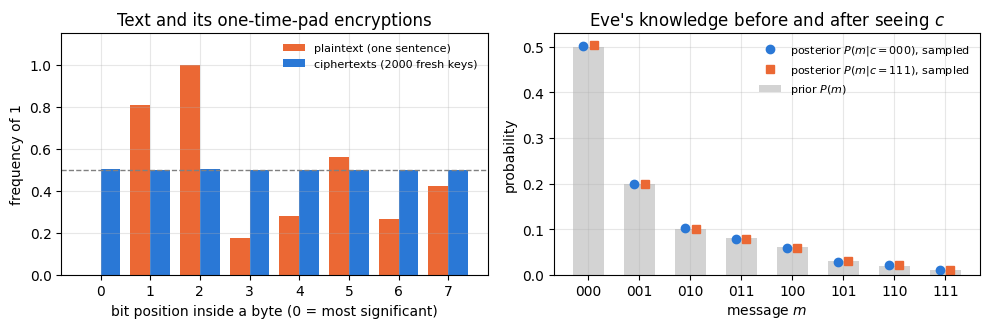

In [6]:
# ==============================================================================
# Figure: bit frequencies of text vs ciphertext, prior vs posterior for two ciphertexts
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
pos = np.arange(8)
ax1.bar(pos - 0.2, freq_plain, 0.4, color=PALETTE[1], label="plaintext (one sentence)")
ax1.bar(pos + 0.2, freq_cipher, 0.4, color=PALETTE[0], label=f"ciphertexts ({N_ENC} fresh keys)")
ax1.axhline(0.5, color="gray", lw=1, ls="--")
ax1.set_xlabel("bit position inside a byte (0 = most significant)"); ax1.set_ylabel("frequency of 1")
ax1.set_title("Text and its one-time-pad encryptions"); ax1.legend(fontsize=8, loc="upper right")
ax1.set_ylim(0, 1.15)
ax2.bar(pos, PRIOR3, 0.6, color="lightgray", label="prior $P(m)$")
for i, c in enumerate((0, 7)):
    ax2.plot(pos + (i - 0.5) * 0.2, P_m_given_c[:, c], MARKERS[i], color=PALETTE[i], ms=6,
             label=f"posterior $P(m\\vert c={c:03b})$, sampled")
ax2.set_xticks(pos, [f"{m:03b}" for m in pos])
ax2.set_xlabel("message $m$"); ax2.set_ylabel("probability")
ax2.set_title("Eve's knowledge before and after seeing $c$"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

All $64$ conditional probabilities $P(c\vert m)$ agree with $1/8$ within the binomial spread, as Eq. (5) demands, and
the posterior after seeing a ciphertext reproduces the prior bar by bar (right panel): Eve's best guess remains the
message $000$, with the same probability $0.5$ as before. The largest deviation of a conditional probability from
$1/8$ is $2.7$ standard errors, as expected for the largest of $64$ estimates. The plug-in mutual information is
$1.4\times10^{-4}$ bits, the size of the estimator bias $1.8\times10^{-4}$ for a mutual information that is exactly
zero. With one fixed key the estimate jumps to the full $H(M)=2.16$ bits.

## 6. Requirements on the key

### 6.1 A key used twice

Suppose Alice encrypts a second message $m_2$ with the key she already used for $m_1$. Eve adds the two ciphertexts
and the key drops out:

$$c_1\oplus c_2=(m_1\oplus k)\oplus(m_2\oplus k)=m_1\oplus m_2. \tag{6}$$

Eve now holds the sum of two messages, which is no longer random. If she knows or guesses one message, she obtains
the other one and the key, $m_2=c_1\oplus c_2\oplus m_1$ and $k=c_1\oplus m_1$. Even without a full guess, natural
language is so redundant that short pieces suffice. Eve slides a likely word, a *crib* such as `" the "`, along
$c_1\oplus c_2$; at the offset where the word sits in one message, adding it reveals the corresponding characters of
the other message, and at most other offsets it produces characters that do not occur in text. The next cell runs
both attacks on two sentences encrypted with the same key.

In [7]:
# ==============================================================================
# Eq. (6): the two-time pad -- known-plaintext recovery and crib dragging
# ==============================================================================
TEXT2 = "the shipment leaves the harbour on friday before the sun rises"[:len(TEXT)]
m1, m2 = text_to_bits(TEXT), text_to_bits(TEXT2)
k_reused = random_bits(key_for(4), m1.size)
c1, c2 = otp(m1, k_reused), otp(m2, k_reused)
x12 = c1 ^ c2
assert np.array_equal(x12, m1 ^ m2)                                     # Eq. (6): the key has dropped out
print("c1      :", bits_to_text(c1)); print("c2      :", bits_to_text(c2))

# attack 1: Eve knows m1 -> she obtains m2 and the key
m2_rec, k_rec = x12 ^ m1, c1 ^ m1
print("m2 = c1+c2+m1:", bits_to_text(m2_rec))
assert np.array_equal(m2_rec, m2) and np.array_equal(k_rec, k_reused)

# attack 2: crib dragging with the guess " the "
ALLOWED = set(b"abcdefghijklmnopqrstuvwxyz ")
crib = np.frombuffer(b" the ", dtype=np.uint8)
x_bytes = np.packbits(x12)
hits = []
for j in range(len(x_bytes) - len(crib) + 1):
    frag = (x_bytes[j:j + len(crib)] ^ crib).tobytes()
    if all(b in ALLOWED for b in frag):
        hits.append((j, frag.decode()))
print(f"\ncrib ' the ' fits as text at {len(hits)} of {len(x_bytes) - len(crib) + 1} offsets:")
for j, frag in hits:
    print(f"  offset {j:2d}: other message reads '{frag}'")
true_offsets = {i for i in range(len(TEXT)) if TEXT.startswith(" the ", i) or TEXT2.startswith(" the ", i)}
assert true_offsets <= {j for j, _ in hits}                              # every true occurrence is found
assert len(hits) <= 3 * len(true_offsets)                                # and few false alarms

c1      : PqKz·2···|···U···t·}··W·····@~·13····|·b··>···Wgg·u·····F
c2      : I|K.·7···m···\···u·?··V··Q···e··9S···5·q··;Z··@"#·~······
m2 = c1+c2+m1: the shipment leaves the harbour on friday before the sun 

crib ' the ' fits as text at 5 of 53 offsets:
  offset 10: other message reads 'nt le'
  offset 14: other message reads 'ezrds'
  offset 19: other message reads 'bridg'
  offset 43: other message reads 'efore'
  offset 48: other message reads 'docum'


Adding the ciphertexts removes the key exactly, and knowing the first sentence gives the second one character by
character, together with the key. The crib `" the "` fits as text at $5$ of the $53$ offsets: the four true
occurrences, two in each sentence, and one false alarm. At the true offsets Eve reads fragments of the other
sentence, `"nt le"`, `"bridg"`, `"efore"` and `"docum"`, and the false alarm gives `"ezrds"`, which is not English
and is discarded. Every readable fragment suggests the next guess ("bridge", "before", "documents"), and this is how
reused pads are broken by hand. The pad is called *one-time* for this reason.

### 6.2 A biased key

The proof of Eq. (5) needed a uniform key. Suppose every key bit is $1$ with probability $\kappa$ instead of $1/2$,
because of a faulty random-number generator. Take a single message bit $m$, uniformly random. Eve sees $c=m\oplus k$
and knows $\kappa$. If $\kappa<1/2$ she guesses $\hat m=c$ and is right whenever $k=0$; if $\kappa>1/2$ she guesses
$\hat m=c\oplus1$. Her probability of guessing correctly is

$$P_{\rm guess}=\max(\kappa,1-\kappa), \tag{7}$$

larger than the $1/2$ of a blind guess for every $\kappa\neq1/2$. In the language of notebook 50, Eve receives the
message through a binary symmetric channel with flip probability $\kappa$ (Section 5.1 there), and the mutual
information per bit is that of Eq. (12) there at a uniform input,

$$I(M{:}C)=1-h(\kappa)\quad\text{per bit},\qquad n\,\big(1-h(\kappa)\big)\ \text{bits for }n\text{ bits}. \tag{8}$$

A key with $\kappa=0.1$ leaks $1-h(0.1)=0.531$ bits per message bit, more than half of the message. Knowledge of the
key is knowledge of the message. A key that Eve can partly predict, because it is biased or because part of it has
leaked, protects the message only to the extent that it remains unpredictable to her. The next cell simulates Eve's
guess and the plug-in mutual information for several values of $\kappa$, with $\kappa=1/2$ as the control in which
nothing leaks, and shows what a key with $\kappa=0.1$ does to the sentence of Section 5.

 kappa | P_guess sim  Eq. (7) | I(M:C) sim  Eq. (8) = 1 - h(kappa)


  0.00 | 1.0000      1.0000  | 1.0000      1.0000


  0.05 | 0.9502      0.9500  | 0.7144      0.7136


  0.10 | 0.9004      0.9000  | 0.5323      0.5310


  0.20 | 0.8000      0.8000  | 0.2781      0.2781


  0.30 | 0.7011      0.7000  | 0.1200      0.1187


  0.40 | 0.6016      0.6000  | 0.0300      0.0290


  0.50 | 0.4984      0.5000  | 0.0000      0.0000
  0.70 | 0.7001      0.7000  | 0.1188      0.1187



key with kappa = 0.1, ciphertext read as text by Eve:
  me·t·fe$··t4he omd$brk·g`8q| ·inu abd`B·ilg·tLm8do·weu~p3
characters intact: 0.404  (expected 0.9^8 = 0.430 +- 0.066)


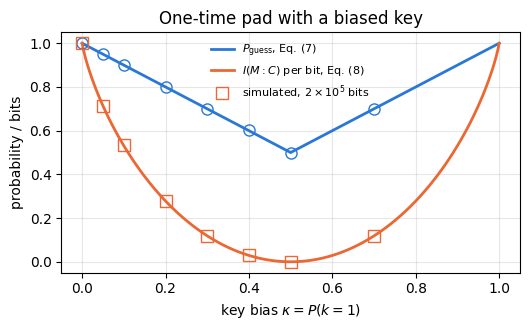

In [8]:
# ==============================================================================
# Eqs. (7)-(8): a biased key -- Eve's guessing probability and the leaked information
# ==============================================================================
N_BIT = 200_000
m_rand = random_bits(key_for(5), N_BIT)
print(" kappa | P_guess sim  Eq. (7) | I(M:C) sim  Eq. (8) = 1 - h(kappa)")
bias_rows = []
for i, kappa in enumerate((0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7)):
    k_b = random_bits(key_for(100 + i), N_BIT, kappa)
    c_b = m_rand ^ k_b
    guess = c_b if kappa <= 0.5 else c_b ^ 1                             # Eve's best guess
    pg = float(np.mean(guess == m_rand))
    I_sim = info_quantities(empirical_joint(m_rand, c_b, 2))["I(X:Y)"]
    bias_rows.append((kappa, pg, I_sim))
    print(f" {kappa:5.2f} | {pg:.4f}      {max(kappa, 1 - kappa):.4f}  | {I_sim:.4f}      {1 - h2(kappa):.4f}")
    assert abs(pg - max(kappa, 1 - kappa)) < 5 * binom_se(max(kappa, 1 - kappa), N_BIT) + 1e-12   # Eq. (7)
    assert abs(I_sim - (1 - h2(kappa))) < 0.005                                                   # Eq. (8)
assert abs(bias_rows[6][1] - 0.5) < 5 * binom_se(0.5, N_BIT) and bias_rows[6][2] < 1e-4   # control: kappa = 1/2

# the sentence of Section 5 encrypted with a key of bias 0.1
c_text = otp(m_bits, random_bits(key_for(6), m_bits.size, 0.1))
intact = float(np.mean(np.all(c_text.reshape(-1, 8) == m_bits.reshape(-1, 8), axis=1)))
print(f"\nkey with kappa = 0.1, ciphertext read as text by Eve:\n  {bits_to_text(c_text)}")
print(f"characters intact: {intact:.3f}  (expected 0.9^8 = {0.9**8:.3f} +- {binom_se(0.9**8, len(TEXT)):.3f})")
assert abs(intact - 0.9**8) < 5 * binom_se(0.9**8, len(TEXT))

fig, ax = plt.subplots(figsize=(5.4, 3.4))
kg = np.linspace(0, 1, 401)
ax.plot(kg, np.maximum(kg, 1 - kg), color=PALETTE[0], lw=2, label="$P_{\\rm guess}$, Eq. (7)")
ax.plot(kg, 1 - h2(kg), color=PALETTE[1], lw=2, label="$I(M:C)$ per bit, Eq. (8)")
ax.plot([r[0] for r in bias_rows], [r[1] for r in bias_rows], MARKERS[0], color=PALETTE[0], mfc="none", ms=8)
ax.plot([r[0] for r in bias_rows], [r[2] for r in bias_rows], MARKERS[1], color=PALETTE[1], mfc="none", ms=8,
        label="simulated, $2\\times10^5$ bits")
ax.set_xlabel("key bias $\\kappa=P(k=1)$"); ax.set_ylabel("probability / bits")
ax.set_title("One-time pad with a biased key"); ax.legend(fontsize=8, loc="upper center")
plt.tight_layout(); plt.show()

The simulated guessing probabilities and mutual informations lie on Eqs. (7) and (8) for every bias, and a uniform
key ($\kappa=1/2$) leaves Eve at $P_{\rm guess}=0.500$ and $I=0$. Both curves are flat near $\kappa=1/2$, so a
slightly biased key leaks little: $\kappa=0.4$ gives Eve a $60\,\%$ guess but only $0.029$ bits per bit. A strongly
biased key is a disaster for text, because a character survives when all eight of its key bits are $0$: with
$\kappa=0.1$ this happens for $0.9^8=43\,\%$ of the characters on average ($40\,\%$ in this sentence), and the
printed ciphertext shows whole pieces of the sentence. A key with $\kappa=0.7$ (last row) is as bad as one with
$\kappa=0.3$, because Eve flips her guess.

### 6.3 A key shorter than the message: Shannon's theorem

The last requirement is length. Shannon proved that no cipher, however clever, can be perfectly secret with fewer
keys than messages (Shannon 1949, Section 10).

**Counting proof.** Fix a ciphertext $c$ that occurs. By Eq. (1) every message $m$ with $P(m)>0$ is still possible
after seeing $c$, so for each such message some key $k_m$ encrypts it into $c$. Two different messages need two
different keys, because decrypting $c$ with one key gives one message. The keys $k_m$ are therefore all distinct, and

$$\#\{\text{keys}\}\;\geq\;\#\{\text{messages}\}. \tag{9}$$

**Entropy form.** The same statement in bits uses only the rules of notebook 50, Section 4. The steps are, from left
to right: perfect secrecy, Eq. (2); a pair of variables is at least as uncertain as one of them; the chain rule;
decryption, which makes $M$ a function of $K$ and $C$ so that $H(M\vert K,C)=0$; and the fact that conditioning
cannot increase entropy, which is $I(K{:}C)\geq0$:

$$H(M)=H(M\vert C)\leq H(M,K\vert C)=H(K\vert C)+H(M\vert K,C)=H(K\vert C)\leq H(K). \tag{10}$$

A perfectly secret key must carry at least as much entropy as the message. Without perfect secrecy the first
equality is lost, but the rest of the chain still gives $H(M\vert C)\leq H(K)$, which bounds what any cipher leaks:

$$I(M{:}C)=H(M)-H(M\vert C)\;\geq\;H(M)-H(K). \tag{11}$$

Every bit by which the key falls short of the message entropy is a bit that Eve learns. For an $n$-bit message the
one-time pad uses $n$ key bits; if the message is redundant, as text is, it can first be compressed to about $H(M)$
bits (notebook 50, Section 3.4) and then needs only that many key bits, which Shannon also pointed out. The next cell
checks Eqs. (9)–(11) by exact enumeration. The cipher adds an $\ell$-bit key, repeated as often as needed, to an
$8$-bit message, for $\ell=1,2,4,8$. For a uniform message Eq. (11) predicts a leak of at least $8-\ell$ bits; the
cell also tests random non-uniform priors.

In [9]:
# ==============================================================================
# Eqs. (9)-(11): a repeated short key, by exact enumeration over all messages and keys
# ==============================================================================
N_BITS = 8


def repeat_key(k, ell, n=N_BITS):
    """The ell-bit key k repeated to n bits (as an integer)."""
    out = 0
    for j in range(0, n, ell):
        out = (out << ell) | k
    return out & (2**n - 1)


rng = numpy_rng(7)
print(" ell | keys | I(M:C), uniform M | n - ell | messages possible per ciphertext")
for ell in (1, 2, 4, 8):
    joint = cipher_joint(np.full(2**N_BITS, 2.0**-N_BITS), np.full(2**ell, 2.0**-ell),
                         lambda m, k: m ^ repeat_key(k, ell), 2**N_BITS)
    I = info_quantities(joint)["I(X:Y)"]
    possible = int(np.count_nonzero(joint[:, 0]))                        # messages consistent with c = 0
    print(f"  {ell}  | {2**ell:4d} | {I:17.4f} | {N_BITS - ell:7d} | {possible} of {2**N_BITS}")
    assert abs(I - (N_BITS - ell)) < TOL                                 # Eq. (11) holds with equality here
    assert possible == 2**ell                                           # Eq. (9): only 2^ell messages survive
    for _ in range(20):                                                  # Eq. (11) for random priors
        P_M = rng.dirichlet(0.3 * np.ones(2**N_BITS))
        jt = cipher_joint(P_M, np.full(2**ell, 2.0**-ell), lambda m, k: m ^ repeat_key(k, ell), 2**N_BITS)
        assert info_quantities(jt)["I(X:Y)"] >= entropy(P_M) - ell - TOL

 ell | keys | I(M:C), uniform M | n - ell | messages possible per ciphertext
  1  |    2 |            7.0000 |       7 | 2 of 256


  2  |    4 |            6.0000 |       6 | 4 of 256


  4  |   16 |            4.0000 |       4 | 16 of 256


  8  |  256 |            0.0000 |       0 | 256 of 256


With a key of $\ell$ bits only $2^\ell$ of the $256$ messages remain possible after Eve sees the ciphertext, and
for a uniform message she learns exactly $8-\ell$ bits: Eq. (11) holds with equality. Only the full eight-bit key
leaves all $256$ messages possible and leaks nothing. For random skewed priors the leak is never smaller than
$H(M)-H(K)$. A short key repeated along a long text is exactly this cipher, and Section 7.2 breaks one by brute
force.

## 7. Key distribution and computational security

### 7.1 The key-distribution problem

Perfect secrecy is easy once Alice and Bob share a secret random key as long as all the messages they will ever
exchange; the whole difficulty has moved into distributing that key. They could meet in person and exchange a disc
of random bits, or trust a courier with a locked briefcase. This works for a few links but does not scale: a video
needs as many fresh key bits as it has bits, every pair of users in a network of $N$ users needs its own key,
$N(N-1)/2$ keys in all, and every courier is an additional party who must be trusted. This
is the **key-distribution problem**. Quantum key distribution addresses exactly this problem: Alice and Bob exchange
quantum states and public classical messages, and at the end they share a key about which Eve knows essentially
nothing.

### 7.2 Computational and information-theoretic security

Encrypted internet traffic avoids the problem differently. **Public-key cryptography**, introduced by Diffie and
Hellman (1976) and by Rivest, Shamir and Adleman (1978), lets two parties who have never met agree on a key over a
public channel, without a courier. The key is then used in a fast cipher with a short key, which, by Eq. (11), is not
perfectly secret. The security of both steps rests on the belief that certain mathematical problems are hard:
computing discrete logarithms in the scheme of Diffie and Hellman, and, in part, factoring the product of two large
primes in the scheme of Rivest, Shamir and Adleman. No fast classical algorithm for these problems is known, but
nobody has proved that none exists. This kind of guarantee is called **computational security**: it holds against an
adversary with limited computing power, and only under an unproven assumption.

**Information-theoretic security** holds against an adversary with unlimited computing power, because she lacks the
information itself. The one-time pad is the standard example, and it is also the target of quantum key
distribution, where this level of security is often called *unconditional*. The word means "not conditioned on
assumptions about computing power"; it does not mean "without assumptions", since the threat model of Section 3.3
still applies.

The difference is visible in a brute-force attack. The next cell encrypts the sentence of Section 5 with a $16$-bit
key repeated along the message, the cipher of Section 6.3 with $\ell=16$, and lets Eve try all $2^{16}=65\,536$ keys,
keeping those that decrypt to lowercase letters and spaces. It then tries the same on the one-time-pad ciphertext,
where for every candidate sentence of the right length there is a key that produces it.

In [10]:
# ==============================================================================
# Brute force: a 16-bit repeated key falls, the one-time pad does not
# ==============================================================================
msg_bytes = np.frombuffer(TEXT.encode("ascii"), dtype=np.uint8)
L_MSG = msg_bytes.size
true_key16 = np.asarray(jax.random.randint(key_for(8), (2,), 0, 256), dtype=np.uint8)
cipher16 = msg_bytes ^ np.resize(true_key16, L_MSG)                   # the two key bytes repeated along the text

allowed = np.zeros(256, dtype=bool); allowed[list(ALLOWED)] = True
t0 = time.perf_counter()
cand = np.arange(256, dtype=np.uint8)
ok_even = allowed[cipher16[0::2][None, :] ^ cand[:, None]].all(1)     # first key byte acts on even positions
ok_odd = allowed[cipher16[1::2][None, :] ^ cand[:, None]].all(1)      # second key byte on odd positions
survivors = [(a, b) for a in cand[ok_even] for b in cand[ok_odd]]     # all 65536 keys, tested byte by byte
t_brute = time.perf_counter() - t0
print(f"repeated 16-bit key: {len(survivors)} of 65536 keys give lowercase text ({t_brute * 1e3:.1f} ms)")
for a, b in survivors:
    plain = cipher16 ^ np.resize(np.array([a, b], dtype=np.uint8), L_MSG)
    print("  key", (int(a), int(b)), "->", plain.tobytes().decode())
assert len(survivors) == 1 and survivors[0] == tuple(true_key16)

# the one-time pad: every sentence of the same length is consistent with the ciphertext
other = "retreat at once and burn every letter you received today"[:L_MSG].ljust(L_MSG)
k_other = c_bits ^ text_to_bits(other)                                  # the key Eve would need for this sentence
print(f"\none-time pad: the key c + m' decrypts the same ciphertext to\n  '{bits_to_text(otp(c_bits, k_other))}'")
assert bits_to_text(otp(c_bits, k_other)) == other

repeated 16-bit key: 1 of 65536 keys give lowercase text (1.1 ms)
  key (155, 68) -> meet me at the old bridge at nine and bring the documents

one-time pad: the key c + m' decrypts the same ciphertext to
  'retreat at once and burn every letter you received today '


Only one of the $65\,536$ keys of the repeated cipher turns the ciphertext into text, the true one, and the search
takes milliseconds because each key byte can be tested on its own. A cipher in practical use has a key long enough
that trying all keys is out of reach, and its security rests on the size of the search and on the absence of
shortcuts, both computational statements. Against
the one-time pad, brute force is useless, because the key $c\oplus m'$ decrypts the ciphertext to any sentence $m'$ of
the same length, "retreat at once" as easily as "meet me", and all keys are equally likely. Eve has no way to tell
which decryption is right, however fast her computer.

### 7.3 Store now, decrypt later

Computational security has an expiry date that nobody knows. Factoring and discrete logarithms, the problems behind
the public-key schemes above, can be solved efficiently on a quantum computer (Shor 1997). The quantum computers built
so far are far too small to attack keys of practical size, but Eve can record encrypted traffic now and decrypt it
once a large enough machine exists. This threat is known as
**store now, decrypt later**, and it matters for any secret that must stay secret for decades, such as medical,
diplomatic or industrial records. Two answers exist. *Post-quantum cryptography* replaces factoring and discrete
logarithms with other mathematical problems believed to be hard even for quantum computers; the key-encapsulation
mechanism ML-KEM of the U.S. National Institute of Standards and Technology is an example (NIST FIPS 203, 2024). Its
security is still computational. *Quantum key distribution* removes the computational assumption from the key
agreement altogether and replaces it with the laws of physics plus a threat model about the devices.

## 8. Authentication

### 8.1 Secrecy is not integrity

Encryption hides a message; **authentication** proves where it comes from and that it has not been changed. These
are different goals, and the one-time pad provides only the first. Eve cannot read the ciphertext, but she can change
it: adding any string $\delta$ to the ciphertext adds the same string to the decrypted message,

$$(c\oplus\delta)\oplus k=m\oplus\delta. \tag{12}$$

If Eve knows the format of a message, for example a payment order with the amount at a fixed position, she can turn
one amount into another without knowing the key, by choosing $\delta=m\oplus m'$ on those positions. The next cell
performs this attack.

In [11]:
# ==============================================================================
# Eq. (12): changing a one-time-pad ciphertext without knowing the key
# ==============================================================================
order = "pay bob 100 euro from account 7"
order_bits = text_to_bits(order)
k_pay = random_bits(key_for(9), order_bits.size)
c_pay = otp(order_bits, k_pay)

forged_order = "pay eve 900 euro from account 7"                    # Eve knows the format; she does not know the key
delta = text_to_bits(order) ^ text_to_bits(forged_order)                # nonzero only where the two orders differ
c_forged = c_pay ^ delta                                                 # Eq. (12)
received = bits_to_text(otp(c_forged, k_pay))
print(f"Alice sends : {order}\nBob decrypts: {received}")
print(f"bits changed by Eve: {int(delta.sum())} of {delta.size}")
assert received == forged_order

Alice sends : pay bob 100 euro from account 7
Bob decrypts: pay eve 900 euro from account 7
bits changed by Eve: 10 of 248


Bob decrypts a perfectly well-formed order, "pay eve 900 euro", and nothing in it reveals the change; Eve flipped $10$
of the $248$ ciphertext bits. Perfect secrecy holds throughout, since Eve learned nothing about the key, and still the
attack succeeded, because secrecy says nothing about what an active Eve can *do*.

### 8.2 The man-in-the-middle attack

Authentication matters most during key agreement. Suppose Alice and Bob run any key-agreement protocol over a public
channel that is not authenticated: a public-key exchange, or quantum key distribution. Eve cuts the line and stands in
the middle (Figure 2a). To Alice she pretends to be Bob, to Bob she pretends to be Alice, and she runs the protocol
once with each of them. At the end Alice shares a key $k_1$ with Eve and Bob shares a key $k_2$ with Eve, and each
believes the key is shared with the other. Every message Alice encrypts with $k_1$ is decrypted by Eve, read or
changed, encrypted again with $k_2$ and passed on to Bob. No physics can prevent this, because each of the two
protocol runs is a perfectly normal run between two parties, with no disturbance to detect.

![The man-in-the-middle attack without authentication, and the authenticated channel with tags computed from a pre-shared key](figures/man_in_the_middle.svg)

**Figure 2.** (a) Without authentication, Eve runs one key agreement with Alice while claiming to be Bob, and one
with Bob while claiming to be Alice; she relays, reads and changes every message. (b) With a short key $a$ shared in
advance, Alice attaches to every public message $m$ a tag $t=f_a(m)$, and Bob accepts only messages whose tag he can
reproduce. Eve does not know $a$, so her forged messages are rejected except with a tiny probability (Section 8.3).

The next cell plays the attack with an idealised key agreement that hands its two participants a fresh shared random
key, which is what quantum key distribution would deliver. Eve's two sessions look exactly like sessions between
Alice and Bob, both of them decrypt valid text, and Eve reads and changes the order on the way.

In [12]:
# ==============================================================================
# Figure 2a: the man-in-the-middle attack on an unauthenticated key agreement
# ==============================================================================
def key_agreement(key, n):
    """Idealised key agreement: the two participants end with the same fresh uniform n-bit key."""
    shared = random_bits(key, n)
    return shared.copy(), shared.copy()


n_order = order_bits.size
k_alice, k_eve1 = key_agreement(key_for(10), n_order)                   # Alice believes she talks to Bob
k_eve2, k_bob = key_agreement(key_for(11), n_order)                     # Bob believes he talks to Alice

c_from_alice = otp(order_bits, k_alice)
read_by_eve = bits_to_text(otp(c_from_alice, k_eve1))                    # Eve decrypts with k1 ...
c_to_bob = otp(text_to_bits(forged_order), k_eve2)                      # ... and re-encrypts her own order with k2
bob_reads = bits_to_text(otp(c_to_bob, k_bob))
print(f"Alice sends : {order}\nEve reads   : {read_by_eve}\nBob reads   : {bob_reads}")
assert read_by_eve == order and bob_reads == forged_order
assert not np.array_equal(k_alice, k_bob)                               # Alice and Bob do not share a key ...
print(f"Alice's and Bob's keys agree on {np.mean(k_alice == k_bob):.2f} of the bits, as two unrelated keys do")

Alice sends : pay bob 100 euro from account 7
Eve reads   : pay bob 100 euro from account 7
Bob reads   : pay eve 900 euro from account 7
Alice's and Bob's keys agree on 0.50 of the bits, as two unrelated keys do


Eve reads Alice's order and delivers her own, and the keys of Alice and Bob agree on about half of the bits, as two
unrelated random strings do. Neither of them can notice anything from the decrypted text alone, since every message
they receive decrypts to valid text.

### 8.3 Authentication tags and key growing

The remedy is a **message authentication code**. Alice and Bob share a short secret key $a$ in advance. Alice attaches
to every public message $m$ a **tag** $t=f_a(m)$ computed from the message and the key, and Bob recomputes it and
accepts the message only if

$$t=f_a(m). \tag{13}$$

Eve, who does not know $a$, must guess the tag of any message she wants to insert or change. Wegman and Carter (1981)
showed that such tags can be made secure against an adversary with unlimited computing power, using a key that grows
only logarithmically with the length of the message. The next cell uses a simple tag for short numerical messages,
$t=(a_1m+a_2)\bmod p$ with a prime $p$ and a key pair $(a_1,a_2)$, and counts, over all $p^2$ keys, how often a forged
message with a forged tag would be accepted when Eve has seen one genuine pair $(m,t)$. A small prime, $p=101$, makes
the forging probability large enough to see. The wrong control repeats the mistake of Section 6.1: a key used for two
tags reveals itself.

In [13]:
# ==============================================================================
# Eq. (13): a one-time authentication tag; Eve's forging probability by exhaustive count
# ==============================================================================
P_PRIME = 101
tag = lambda a1, a2, m: (a1 * m + a2) % P_PRIME                         # tag t = f_a(m), key a = (a1, a2)

m_seen, a_true = 42, (17, 88)
t_seen = tag(*a_true, m_seen)
A1, A2 = np.meshgrid(np.arange(P_PRIME), np.arange(P_PRIME), indexing="ij")
consistent = tag(A1, A2, m_seen) == t_seen                              # keys Eve cannot exclude after seeing (m, t)
print(f"keys consistent with the observed pair (m, t) = ({m_seen}, {t_seen}): {consistent.sum()} of {P_PRIME**2}")
best = 0.0
for m_forged in (0, 7, 43, 100):                                        # any other message ...
    accept = np.array([np.mean(tag(A1[consistent], A2[consistent], m_forged) == t) for t in range(P_PRIME)])
    best = max(best, accept.max())                                      # ... with the best possible tag guess
    assert np.allclose(accept, 1 / P_PRIME)                             # every tag value equally likely to Eve
print(f"best forging probability: {best:.5f} = 1/p = {1 / P_PRIME:.5f}")

# wrong control: the same key tags two messages -> two linear equations fix (a1, a2)
m_b = 77; t_b = tag(*a_true, m_b)
a1_rec = ((t_seen - t_b) * pow(m_seen - m_b, -1, P_PRIME)) % P_PRIME
a2_rec = (t_seen - a1_rec * m_seen) % P_PRIME
print(f"two tags with one key: Eve solves for the key {(a1_rec, a2_rec)} (true {a_true}) and can tag anything")
assert (a1_rec, a2_rec) == a_true

keys consistent with the observed pair (m, t) = (42, 95): 101 of 10201
best forging probability: 0.00990 = 1/p = 0.00990
two tags with one key: Eve solves for the key (17, 88) (true (17, 88)) and can tag anything


After seeing one genuine pair, $101$ of the $10\,201$ keys remain possible for Eve, one for each value of $a_1$. The
tag of another message $m'$ is $t'=t+a_1(m'-m)\bmod p$, and because $p$ is prime and $m'\neq m$, each of the $101$
values of $t'$ belongs to exactly one remaining $a_1$, so any forgery is accepted with probability exactly $1/p$. With
a prime of $64$ bits this probability is about $10^{-19}$ per attempt. A tag key used twice is broken by solving
two linear equations, so authentication, like the one-time pad, consumes fresh key bits for every message, though far
fewer than encryption.

Authentication therefore requires a secret shared in advance, and no protocol, classical or quantum, can create
a shared secret between two parties who share nothing and cannot authenticate each other, since Eve could always play
the man in the middle. Quantum key distribution consequently does not start from nothing. Alice and Bob begin with a
short pre-shared key, use part of it to authenticate the public discussion of the first run, and obtain a long new
key, of which a small part replaces the authentication key consumed and the rest is available for encryption. The
protocol therefore performs **key growing**: the pre-shared key is the only secret that must travel by courier, and
only once.

## 9. Privacy amplification

### 9.1 Two bits into one

The last classical ingredient handles a key that is shared but not perfectly secret. After the public parity checks of
[notebook 50, Section
6.3](../ch14_quantum_communication_and_cryptography/50_information_entropy_and_noisy_channels.ipynb) Alice and Bob
hold the same string $x$ of $n$ bits, but Eve has heard every announced parity, and in a quantum protocol she may also
have learned something by eavesdropping. **Privacy amplification** compresses $x$ into a shorter string $k=f(x)$ about
which Eve knows essentially nothing (Bennett, Brassard and Robert 1988).

The smallest example has two bits. Suppose Eve knows $x_1$, while $x_2$ is uniformly random and independent of
everything she knows. Alice and Bob keep only $k=x_1\oplus x_2$. For every value of $x_1$, the bit $k$ is $x_2$ or its
negation, uniform in both cases, so

$$H(K\vert E)=H(x_1\oplus x_2\vert x_1)=H(x_2)=1,\qquad I(K{:}E)=0. \tag{14}$$

One bit was sacrificed and all of Eve's knowledge removed. Alice and Bob did not even need to know *which* bit Eve
knew, because the sum works either way. They do need to know *how much* she knows: if Eve knows both bits, or the
sum $x_1\oplus x_2$ itself, the output is no secret at all. The next cell computes Eq. (14) from exact joint tables,
with these two cases as wrong controls.

In [14]:
# ==============================================================================
# Eq. (14): privacy amplification of two bits by their sum
# ==============================================================================
def joint_k_e(eve_view):
    """Exact joint table P(k, e) for k = x1 XOR x2 and Eve's view e = eve_view(x1, x2), x1, x2 uniform bits."""
    table = np.zeros((2, 4))
    for x1 in (0, 1):
        for x2 in (0, 1):
            table[x1 ^ x2, eve_view(x1, x2)] += 0.25
    return table


views = {"Eve knows x1": (lambda x1, x2: x1, 0.0), "Eve knows x2": (lambda x1, x2: x2, 0.0),
         "Eve knows x1 and x2 (control)": (lambda x1, x2: 2 * x1 + x2, 1.0),
         "Eve knows x1 + x2 (control)": (lambda x1, x2: x1 ^ x2, 1.0)}
for name, (view, I_expected) in views.items():
    q = info_quantities(joint_k_e(view))
    print(f"{name:30s}: H(K|E) = {q['H(X|Y)']:.3f}, I(K:E) = {q['I(X:Y)']:.3f} bits")
    assert abs(q["I(X:Y)"] - I_expected) < TOL                          # Eq. (14) and its controls

Eve knows x1                  : H(K|E) = 1.000, I(K:E) = 0.000 bits
Eve knows x2                  : H(K|E) = 1.000, I(K:E) = 0.000 bits
Eve knows x1 and x2 (control) : H(K|E) = 0.000, I(K:E) = 1.000 bits
Eve knows x1 + x2 (control)   : H(K|E) = 0.000, I(K:E) = 1.000 bits


### 9.2 Random linear hashing

For long strings Alice and Bob generalise the sum. They choose a random binary matrix $G$ with $\ell$ rows and $n$
columns, announce it publicly *after* Eve's information has been fixed, so that she cannot aim her eavesdropping at
the parities that become the key, and keep

$$k=G\,x\pmod2, \tag{15}$$

so that each of the $\ell$ key bits is the parity of a random subset of the bits of $x$. To see how much Eve learns
about $k$, take a model in which her knowledge is itself linear: she knows $r$ independent parities of $x$, the rows
of a binary matrix $P$, for example the parities announced during error correction or individual bits that she
measured (rows with a single $1$). For a uniform string $x$, any set of parities $Ax$ is uniformly distributed over
$2^{\operatorname{rank}A}$ values, where the rank is taken with arithmetic modulo $2$: the linear map $x\mapsto Ax$
has $2^{\operatorname{rank}A}$ possible values, and each of them is reached by the same number of strings $x$. So
$H(Ax)=\operatorname{rank}A$. The chain rule of notebook 50 then gives Eve's remaining uncertainty about the key
exactly,

$$H(K\vert E)=H(Gx,Px)-H(Px)=\operatorname{rank}\begin{pmatrix}P\\G\end{pmatrix}-\operatorname{rank}P. \tag{16}$$

The key is perfectly secret, $H(K\vert E)=\ell$, when every row of $G$ is independent of the rows of $P$ and of the
rows of $G$ before it, and each row that fails this test hands Eve one bit. Row $j+1$ of a random $G$ is uniform over
$2^n$ strings, of which at most $2^{r+j}$ lie in the span of the previous rows, so it fails with probability at most
$2^{r+j-n}$. Summing over the $\ell$ rows bounds the shortfall $\ell-H(K\vert E)$ of the key from a perfectly secret
one, and with it the information Eve keeps, $I(K{:}E)=H(K)-H(K\vert E)\le\ell-H(K\vert E)$, in this linear model and on
average over the choice of $G$:

$$\overline{I(K{:}E)}\;\leq\;\ell-\overline{H(K\vert E)}\;\leq\;\sum_{j=0}^{\ell-1}2^{\,r+j-n}\;<\;2^{-s},
\qquad s=n-r-\ell. \tag{17}$$

Alice and Bob shorten the key by Eve's $r$ bits of knowledge plus a **safety margin** of $s$ bits, and Eve's
remaining information falls exponentially with $s$. They need not know which bits or parities Eve holds, only an upper
bound on how many, exactly as in the two-bit example. A fixed rule such as "keep the first $\ell$ bits" has no such
guarantee: it works only if Eve's knowledge happens to sit elsewhere.

The first cell below checks Eq. (16) by brute force on strings of $n=10$ bits: for random $P$ and $G$ it enumerates
all $1024$ strings, builds the joint table of $(Gx,Px)$, and compares the conditional entropy with the ranks. The
second cell takes $n=128$ and an Eve who knows $r=48$ of the bits, scans the key length $\ell$, and compares the
random hash of Eq. (15) with the fixed rule.

In [15]:
# ==============================================================================
# Eq. (16): H(K|E) from ranks modulo 2, checked by enumerating all strings
# ==============================================================================
def gf2_rank_profile(rows):
    """Rank modulo 2 after each row is added (rows given as Python ints, one bit per column).

    ALGORITHM  Gaussian elimination keyed by leading bit: reduce each new row by the stored pivots with the same
               leading bit; a nonzero remainder becomes a new pivot and raises the rank by one.
    """
    pivots, profile = {}, []
    for r in rows:
        while r:
            lead = r.bit_length() - 1
            if lead in pivots:
                r ^= pivots[lead]
            else:
                pivots[lead] = r
                break
        profile.append(len(pivots))
    return profile


def rows_as_ints(M):
    """Binary matrix (rows x n) -> list of Python ints."""
    return [int("".join(map(str, row)), 2) if row.size else 0 for row in M]


def H_K_given_E(P, G):
    """Eq. (16): rank [P; G] - rank P."""
    prof = gf2_rank_profile(rows_as_ints(P) + rows_as_ints(G))
    rank_P = prof[len(P) - 1] if len(P) else 0
    return prof[-1] - rank_P


n_small = 10
X_all = ((np.arange(2**n_small)[:, None] >> np.arange(n_small - 1, -1, -1)) & 1).astype(np.int64)   # all strings
rng = numpy_rng(12)
n_checked = 0
for r in (0, 2, 4, 6):
    for ell in (1, 3, 4, 6):
        for _ in range(5):
            P = rng.integers(0, 2, (r, n_small)); G = rng.integers(0, 2, (ell, n_small))
            k_val = (X_all @ G.T % 2) @ (2 ** np.arange(ell - 1, -1, -1))           # key as an integer
            e_val = (X_all @ P.T % 2) @ (2 ** np.arange(r - 1, -1, -1)) if r else np.zeros(2**n_small, int)
            table = np.zeros((2**ell, 2**max(r, 1))); np.add.at(table, (k_val, e_val), 2.0**-n_small)
            H_brute = info_quantities(table)["H(X|Y)"]
            assert abs(H_brute - H_K_given_E(P, G)) < TOL
            n_checked += 1
print(f"Eq. (16) agrees with brute-force enumeration of all 1024 strings in {n_checked} random cases")

Eq. (16) agrees with brute-force enumeration of all 1024 strings in 80 random cases


ell =  40 (s =  40): Eve's information, random hash 0.0000 (parities 0.0000), Eq. (17) bound 9.09e-13; first ell bits 14.88
ell =  64 (s =  16): Eve's information, random hash 0.0000 (parities 0.0000), Eq. (17) bound 1.53e-05; first ell bits 23.99
ell =  74 (s =   6): Eve's information, random hash 0.0150 (parities 0.0200), Eq. (17) bound 1.56e-02; first ell bits 27.67
ell =  78 (s =   2): Eve's information, random hash 0.2500 (parities 0.1900), Eq. (17) bound 2.50e-01; first ell bits 29.16
ell =  80 (s =   0): Eve's information, random hash 0.7950 (parities 0.8000), Eq. (17) bound 1.00e+00; first ell bits 29.89
ell =  96 (s = -16): Eve's information, random hash 16.0000 (parities 16.0000), Eq. (17) bound    -    ; first ell bits 35.95


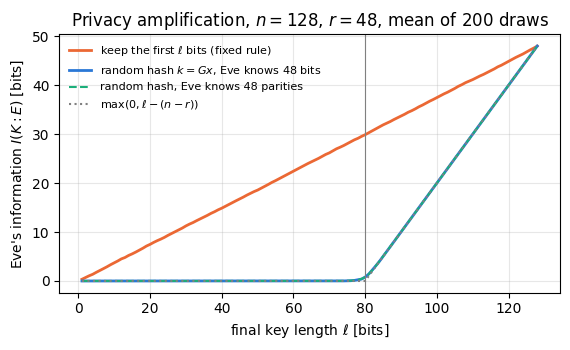

In [16]:
# ==============================================================================
# Eqs. (15)-(17): Eve knows r = 48 of n = 128 bits; random hash vs keeping the first ell bits
# ==============================================================================
N_PA, R_EVE, N_DRAW = 128, 48, 200
rng = numpy_rng(13)
ells = np.arange(1, N_PA + 1)
I_random = np.zeros((N_DRAW, N_PA)); I_parity = np.zeros((N_DRAW, N_PA)); I_first = np.zeros((N_DRAW, N_PA))
for d in range(N_DRAW):
    known = rng.choice(N_PA, R_EVE, replace=False)                       # positions Eve knows (unknown to Alice, Bob)
    P_bits = np.zeros((R_EVE, N_PA), dtype=np.int64); P_bits[np.arange(R_EVE), known] = 1
    P_par = rng.integers(0, 2, (R_EVE, N_PA))                            # or: r random parities
    G = rng.integers(0, 2, (N_PA, N_PA))                                 # its first ell rows hash to ell bits
    for P, I_out in ((P_bits, I_random), (P_par, I_parity)):
        prof = gf2_rank_profile(rows_as_ints(P) + rows_as_ints(G))
        rank_P = prof[R_EVE - 1]
        I_out[d] = ells - (np.array(prof[R_EVE:]) - rank_P)             # Eq. (16): I = ell - H(K|E)
    I_first[d] = np.cumsum(np.isin(np.arange(N_PA), known))             # fixed rule: Eve knows those of her bits
                                                                         # that lie among the first ell

mean_rand, mean_par, mean_first = I_random.mean(0), I_parity.mean(0), I_first.mean(0)
bound = np.array([sum(2.0 ** (R_EVE + j - N_PA) for j in range(ell)) for ell in ells])   # Eq. (17)
for ell in (40, 64, 74, 78, 80, 96):
    s = N_PA - R_EVE - ell
    bnd = f"{bound[ell - 1]:.2e}" if s >= 0 else "   -    "
    print(f"ell = {ell:3d} (s = {s:3d}): Eve's information, random hash {mean_rand[ell - 1]:.4f} (parities "
          f"{mean_par[ell - 1]:.4f}), Eq. (17) bound {bnd}; first ell bits {mean_first[ell - 1]:.2f}")
safe = ells <= N_PA - R_EVE - 20
assert np.all(I_random[:, safe] == 0) and np.all(I_parity[:, safe] == 0)          # s >= 20: nothing leaks
near = (ells > N_PA - R_EVE - 8) & (ells <= N_PA - R_EVE)
se_near = np.sqrt(I_random[:, near].var(0) / N_DRAW + 1e-12)
assert np.all(mean_rand[near] <= bound[near] + 5 * se_near)                        # Eq. (17) near s = 0
over = ells > N_PA - R_EVE
assert np.all(I_random[:, over] >= (ells[over] - (N_PA - R_EVE))[None, :])        # ell > n - r: Eve knows the excess
assert abs(mean_first[63] - 64 * R_EVE / N_PA) < 1.0                               # control: fixed rule leaks r/n

fig, ax = plt.subplots(figsize=(5.8, 3.6))
ax.plot(ells, mean_first, color=PALETTE[1], lw=2, label="keep the first $\\ell$ bits (fixed rule)")
ax.plot(ells, mean_rand, color=PALETTE[0], lw=2, label="random hash $k=Gx$, Eve knows 48 bits")
ax.plot(ells, mean_par, "--", color=PALETTE[2], lw=1.5, label="random hash, Eve knows 48 parities")
ax.plot(ells, np.maximum(ells - (N_PA - R_EVE), 0), ":", color="gray", lw=1.5, label="$\\max(0,\\ell-(n-r))$")
ax.axvline(N_PA - R_EVE, color="gray", lw=0.8)
ax.set_xlabel("final key length $\\ell$ [bits]"); ax.set_ylabel("Eve's information $I(K:E)$ [bits]")
ax.set_title(f"Privacy amplification, $n={N_PA}$, $r={R_EVE}$, mean of {N_DRAW} draws")
ax.legend(fontsize=8, loc="upper left"); plt.tight_layout(); plt.show()

Eq. (16) agrees with the brute-force conditional entropy in all $80$ small cases. For $n=128$ and an Eve who knows
$48$ bits, the random hash leaves her with no information at all, in every one of the $200$ draws, as long as the key
is at least $20$ bits shorter than $n-r=80$. Close to $\ell=80$ her average information rises to $0.015$ bits at
$s=6$, $0.25$ at $s=2$ and $0.795$ at $s=0$, where the exact mean is $0.85$, in agreement with the bound of Eq. (17),
which is nearly reached for $s\geq1$; beyond $\ell=80$ she necessarily knows at least $\ell-80$ bits of the key. The
result is the same when Eve holds $48$ random parities instead of $48$ bits, the kind of knowledge that public error
correction gives away. The fixed rule leaks from the first bit on: the first $\ell$ bits contain on average
$48/128=37.5\,\%$ of Eve's bits, and keeping $64$ of them hands her about $24$.

Real eavesdroppers are not restricted to linear knowledge, and in quantum key distribution Eve may even hold quantum
systems. Bennett, Brassard, Crépeau and Maurer (1995) showed that random hashing still works when only a suitable
bound on Eve's knowledge is known, and the security proofs of quantum key distribution extend this to quantum
adversaries. The rule of thumb survives in every case: subtract an upper bound on Eve's knowledge and a safety margin
from the length of the reconciled key.

## 10. From a shared secret key to quantum key distribution

Secrecy against an eavesdropper with unlimited computing power is possible, but only with a uniformly random secret
key at least as long as the message, used once. Turning a noisy, partly known shared string into such a key takes two
public steps: error correction by parity checks, which costs about $h(Q)$ bits per key bit (notebook 50), and privacy
amplification, which removes Eve's knowledge at the cost of as many bits as she might know. The public discussion must
be authenticated, which requires a short key shared in advance, so the whole procedure grows an existing key.

What classical physics cannot provide is the bound on Eve's knowledge. On a classical channel Eve can copy every
signal without leaving a trace, so without assumptions about her equipment Alice and Bob cannot bound how much she
knows, and no amount of hashing helps if that amount might be everything. Quantum mechanics changes exactly this
point. An unknown quantum state cannot be copied, and any attempt to learn about it disturbs it; Alice and Bob can
therefore estimate how much Eve can know from the error rate they observe on their own data. That estimate fixes how
much privacy amplification must remove, and the remainder is a key for the one-time pad.

## 11. Key takeaways

* **A security claim needs a threat model.** It states what Eve can read, change and compute, and what is trusted;
  by Kerckhoffs's principle she knows the whole protocol and only the key is secret.
* **Perfect secrecy is independence.** $P(M\vert C)=P(M)$, equivalently $I(M{:}C)=0$, Eqs. (1)–(3); Eve's posterior
  equals her prior whatever her computing power.
* **The one-time pad is perfectly secret.** $c=m\oplus k$ with a uniform key gives $P(c\vert m)=2^{-n}$ for every
  message, Eq. (5); the simulation found all $64$ conditional probabilities at $1/8$ and a plug-in $I(M{:}C)$ at the
  level of the estimator bias.
* **Every misuse of the key leaks.** A reused key gives $c_1\oplus c_2=m_1\oplus m_2$ and broke two sentences; a key
  with bias $\kappa$ leaks $1-h(\kappa)$ bits per bit, $0.531$ at $\kappa=0.1$; a key shorter than the message leaks
  at least $H(M)-H(K)$, and perfect secrecy needs $H(K)\geq H(M)$ (Shannon).
* **Computational security can expire.** Public-key methods rest on factoring and discrete logarithms, which a large
  quantum computer solves (Shor); recorded traffic can be decrypted later. Information-theoretic security does not
  depend on Eve's computing power.
* **Secrecy does not imply authenticity.** A one-time-pad ciphertext can be altered without the key, and an
  unauthenticated key agreement falls to the man in the middle. Authentication tags need a short pre-shared key, so
  quantum key distribution grows an existing key.
* **Privacy amplification removes partial knowledge.** Hashing with a random binary matrix to $\ell=n-r-s$ bits left
  an Eve who knew $r=48$ of $128$ bits with no information whenever $s\geq20$, while keeping a fixed subset of bits
  leaked in proportion.

## 12. Exercises

1. ★ **Two messages, one key.** Alice sends $c_1=1100$ and $c_2=0110$, both encrypted with the same key. Eve knows
   that $m_1=1010$. Find $m_2$ and the key.
2. ★ **A one-bit pad with a biased key.** The key bit is $0$ with probability $3/4$ and the message is a fair bit.
   With what probability can Eve guess the message from the ciphertext, and how many bits does the ciphertext leak?
   Check both with the cell of Section 6.2.
3. ★ **A curious receiver.** A hospital sends records to a laboratory, encrypted with a key known only to both sites.
   An employee of the laboratory reads the decrypted records and sells statistics. Classify the parties, and say which
   question of the threat model was answered too optimistically.
4. ★★ **Compress, then encrypt.** A source emits bits that are $1$ with probability $0.1$. How many key bits per
   source bit does perfect secrecy require at least, according to Eq. (10)? Encrypt a Huffman-compressed string from
   notebook 50, Section 3.4, with a one-time pad, and verify that the key used per source bit approaches this value.
5. ★★ **Key bookkeeping in a network.** A company of $N=1000$ employees wants one-time-pad links between all pairs,
   each pair exchanging $1$ megabyte of messages per day. How many keys are needed, and how much key material must the
   courier deliver per day? Compare with a design in which a trusted central server shares one key with each
   employee and relays every message, and name the new assumption in the threat model.
6. ★★ **Three bits into one.** Eve knows the parity $x_1\oplus x_2$ of a uniformly random string $x_1x_2x_3$. Which of
   the seven nonzero parities $k=g\cdot x$ ($g\in\{0,1\}^3$) are perfectly secret to her? Check your answer with
   `H_K_given_E` and with Eq. (16).
7. ★★★ **The cost of a margin.** Repeat the simulation of Section 9.2 for $n=64$ and $r=16$, and estimate the mean
   information of Eve at $s=0,1,\dots,8$ from many draws. Compare with the bound of Eq. (17), and find for which $s$
   the probability that Eve learns anything falls below $1\,\%$.

*Check values.* 1: $c_1\oplus c_2=1010=m_1\oplus m_2$, so $m_2=0000$ and $k=c_1\oplus m_1=0110$. 2:
$P_{\rm guess}=3/4$, leak $1-h(1/4)=0.189$ bits. 3: the hospital is an honest party, the laboratory is
honest-but-curious; the question which parties follow the protocol and which may be curious was answered too
optimistically, and no encryption of the channel can protect data from its own receiver. 4: $h(0.1)=0.469$ key bits
per source bit; the Huffman code on blocks of six tosses needs $0.470$. 5: $N(N-1)/2=499\,500$ keys and $499.5$
gigabytes of fresh key per day, each byte delivered to both ends of its link; with a central server only $1000$ keys,
but the server reads every message and must be trusted. 6: only $g=110$, the known parity itself, is not secret; the
other six parities are ($H(K\vert E)=1$), including $g=100$ and $g=010$, because one bit of a pair whose parity is
known is still uniform. 7: for $n=64$, $r=16$ the mean information is $0.85$, $0.46$, $0.24$, $0.12$, $0.062$,
$0.031$ and $0.016$ bits for $s=0,\dots,6$ (exact values; a simulation agrees within its statistical error), close
to the bound of Eq. (17) from $s=1$ on; the probability that Eve learns anything is close to $2^{-s}$ and falls below
$1\,\%$ at $s=7$ ($0.78\,\%$).

## References

* C. E. Shannon, *Communication theory of secrecy systems*, Bell Syst. Tech. J. **28**, 656 (1949),
  doi:10.1002/j.1538-7305.1949.tb00928.x — the assumption that the enemy knows the system, perfect secrecy as equality
  of a posteriori and a priori probabilities, Theorem 6, the bound on the number of keys, the key uncertainty needed
  to conceal the message, the Vernam system as a perfect system, and compression before encryption.
* G. S. Vernam, *Cipher printing telegraph systems for secret wire and radio telegraphic communications*, J. Am. Inst.
  Electr. Eng. **45**, 109 (1926), doi:10.1109/JAIEE.1926.6534724 — the teleprinter cipher of the U.S. Army Signal
  Corps to which the one-time pad goes back.
* A. Kerckhoffs, *La cryptographie militaire*, Journal des sciences militaires **9**, 5 and 161 (1883) — the six
  requirements of a military cipher, the second of which is Kerckhoffs's principle.
* W. Diffie and M. E. Hellman, *New directions in cryptography*, IEEE Trans. Inf. Theory **22**, 644 (1976),
  doi:10.1109/TIT.1976.1055638 — public key distribution whose security rests on the difficulty of computing
  logarithms modulo a prime.
* R. L. Rivest, A. Shamir and L. Adleman, *A method for obtaining digital signatures and public-key cryptosystems*,
  Commun. ACM **21**, 120 (1978), doi:10.1145/359340.359342 — the RSA cryptosystem, whose security rests in part on
  the difficulty of factoring.
* P. W. Shor, *Polynomial-time algorithms for prime factorization and discrete logarithms on a quantum computer*, SIAM
  J. Comput. **26**, 1484 (1997), doi:10.1137/S0097539795293172 — efficient quantum algorithms for the two problems
  behind these cryptosystems.
* National Institute of Standards and Technology, *Module-lattice-based key-encapsulation mechanism standard*, FIPS
  203 (2024), doi:10.6028/NIST.FIPS.203 — the post-quantum key-encapsulation mechanism ML-KEM, believed secure against
  adversaries with a quantum computer.
* M. N. Wegman and J. L. Carter, *New hash functions and their use in authentication and set equality*, J. Comput.
  Syst. Sci. **22**, 265 (1981), doi:10.1016/0022-0000(81)90033-7 — authentication that an enemy with unlimited
  computing power cannot forge, with a key that grows logarithmically with the message length.
* C. H. Bennett, G. Brassard and J.-M. Robert, *Privacy amplification by public discussion*, SIAM J. Comput. **17**,
  210 (1988), doi:10.1137/0217014 — distilling, by public discussion, a shorter string about which Eve has nearly no
  information from a string about which she has partial information.
* C. H. Bennett, G. Brassard, C. Crépeau and U. M. Maurer, *Generalized privacy amplification*, IEEE Trans. Inf.
  Theory **41**, 1915 (1995), doi:10.1109/18.476316 — privacy amplification by random hashing when only a bound on
  Eve's knowledge is known.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/